In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [7]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')
# text svg

'notebook'

In [14]:
task = [
    'PhonemeSequence',
    # 'SentenceRep',
    # 'LexicalDelay',
    # 'LexicalNoDelay',
    # 'PictureNaming',
]

ref='bipolar'

stats_paths = []
stats_paths.extend(
    BIDSPath(
        root=f'../results/{t}({ref})',
        datatype='HGA',
        suffix='time',
        check=False,
    ).match()
    for t in task
)

stats_paths = np.concatenate(stats_paths).tolist()

coords = []
for path in tqdm(stats_paths):
    df = pd.read_csv(path)
    coords.append(df)
    
coords = pd.concat(coords)

# rename INS to 'Insula'
coords.loc[coords.roi == 'INS', 'roi'] = 'Insula'

# combine HG to STG
# coords.loc[coords.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
coords.loc[coords.roi == 'PrG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'PoG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'Subcentral', 'roi'] = 'SMC'

coords = (
    coords.groupby('channel')
    .agg({
        'value': 'mean',
        'x': 'first',
        'y': 'first',
        'z': 'first',
        'roi': 'first',
        'label': 'first',
        'phase': 'first',
        'hemi': 'first',
        'subject': 'first',
        'description': 'first',
        'task': 'first'
    })
    .reset_index()
    .rename(columns={'value': 'HGA'})
)
# coords = coords[coords.roi=='HG']

fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)

coords[['x','y','z']] = coords[['x','y','z']].values + translation
coords.head()

100%|██████████| 226/226 [00:02<00:00, 98.10it/s] 


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0019_RIIH5-6,0.043527,12.667761,-77.196118,-8.479936,OPC,ctx_rh_Pole_occipital,Audio,R,D0019,Repeat,PhonemeSequence
1,D0019_RLSO3-4,-0.032396,26.606435,-30.993087,-37.504424,Intersection,Intersection,Go,R,D0019,Repeat,PhonemeSequence
2,D0019_RLSO7-8,0.097957,19.238193,6.576256,-50.833707,PhG,ctx_rh_G_oc-temp_med-Parahip,Audio,R,D0019,Repeat,PhonemeSequence
3,D0019_RMOS3-4,0.050794,16.805729,-39.437861,50.050771,SPL,ctx_rh_G_parietal_sup,Go,R,D0019,Repeat,PhonemeSequence
4,D0019_ROG12-13,0.048511,32.530392,-66.383106,-2.804032,OccS,ctx_rh_S_oc_sup_and_transversal,Audio,R,D0019,Repeat,PhonemeSequence


## fsaverge

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


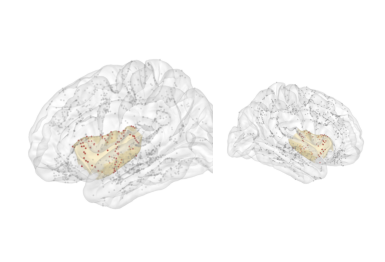

In [9]:
coords_unique = coords.drop_duplicates(subset=['channel'])

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

cord = coords_unique[['x', 'y', 'z']].values
insula_mask = coords_unique['roi'].eq('Insula').values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & (lh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.3,
            )

        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & (rh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.5,
            )

        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

lh_brain.close()
rh_brain.close()

# fig.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')

# plt.tight_layout()
plt.show()

## MNI

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


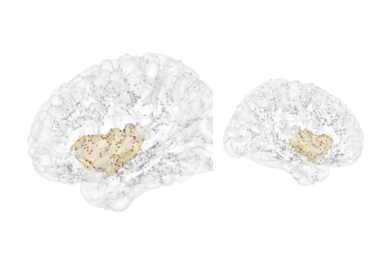

In [15]:
# cvs_avg35_inMNI152 visualization - coordinates already in MNI space from package_HGA.py
coords_unique = coords.drop_duplicates(subset=['channel'])

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# Coordinates are already in cvs_avg35_inMNI152 space (transformed in package_HGA.py)
cord_fsavg = coords_unique[['x', 'y', 'z']].values
insula_mask = coords_unique['roi'].eq('Insula').values

# 计算 fsaverage 和 cvs_avg35_inMNI152 之间的平移向量
# fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
# cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
# translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)

# # 应用平移
# cord = cord_fsavg + translation

cord = cord_fsavg

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & (lh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.3,
            )

        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & (rh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.5,
            )

        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

lh_brain.close()
rh_brain.close()

# fig.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
# Insula region classification function and visualization
def classify_insula_ap(coords_df, y_threshold=0):
    """
    Classify insula electrodes into AIC (anterior insula cortex) and PIC (posterior insula cortex)
    
    Classification scheme:
    AIC (red team): 
      - All G_insular_short (regardless of coordinates)
      - All S_circular_insula_ant (regardless of coordinates)  
      - All S_circular_insula_sup with Y > 0
      - All S_circular_insula_inf with Y > 0
    
    PIC (blue team):
      - All G_Ins_lg_and_S_cent_ins (regardless of coordinates)
      - All S_circular_insula_sup with Y <= 0
      - All S_circular_insula_inf with Y <= 0
    """
    # Copy data to avoid modifying original data
    coords_classified = coords_df.copy()
    
    # Initialize new classification
    coords_classified['insula_region'] = coords_classified['roi']
    
    # Only process insula electrodes
    insula_mask = coords_classified['roi'] == 'Insula'
    
    # AIC classification conditions
    aic_conditions = (
        (coords_classified['label'].str.contains('G_insular_short')) |
        (coords_classified['label'].str.contains('S_circular_insula_ant')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] > y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] > y_threshold))
    )
    
    # PIC classification conditions  
    pic_conditions = (
        (coords_classified['label'].str.contains('G_Ins_lg_and_S_cent_ins')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] <= y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] <= y_threshold))
    )
    
    # Apply classification
    coords_classified.loc[insula_mask & aic_conditions, 'roi'] = 'AIC'
    coords_classified.loc[insula_mask & pic_conditions, 'roi'] = 'PIC'
    
    return coords_classified

# Apply classification function
coords_ap = classify_insula_ap(coords)

# Statistical results
print(f"AIC electrode count: {len(coords_ap[coords_ap['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(coords_ap[coords_ap['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = coords_ap[coords_ap['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
coords_ap.head()

AIC electrode count: 73
PIC electrode count: 74


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task,insula_region
0,D0019_RIIH5-6,0.043527,11.886836,-94.046488,10.403848,OPC,ctx_rh_Pole_occipital,Audio,R,D0019,Repeat,PhonemeSequence,OPC
1,D0019_RLSO3-4,-0.032396,25.825510,-47.843456,-18.620640,Intersection,Intersection,Go,R,D0019,Repeat,PhonemeSequence,Intersection
2,D0019_RLSO7-8,0.097957,18.457267,-10.274114,-31.949923,PhG,ctx_rh_G_oc-temp_med-Parahip,Audio,R,D0019,Repeat,PhonemeSequence,PhG
3,D0019_RMOS3-4,0.050794,16.024804,-56.288230,68.934555,SPL,ctx_rh_G_parietal_sup,Go,R,D0019,Repeat,PhonemeSequence,SPL
4,D0019_ROG12-13,0.048511,31.749467,-83.233475,16.079752,OccS,ctx_rh_S_oc_sup_and_transversal,Audio,R,D0019,Repeat,PhonemeSequence,OccS


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


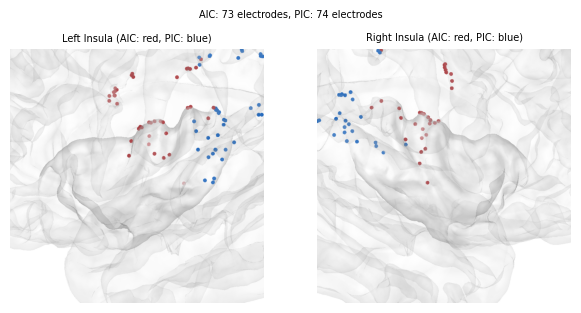

In [12]:
# 3D Brain with AIC/PIC分区显示 - Electrodes already in cvs_avg35_inMNI152 space
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

# 读取aparc.a2009s labels (cvs_avg35_inMNI152)
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影 (cvs_avg35_inMNI152)
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# 获取分区后的insula电极 - coordinates already in cvs_avg35_inMNI152 space
coords_unique_ap = coords_ap[coords_ap.roi.isin(['AIC', 'PIC'])].drop_duplicates(subset=['channel'])
cord = coords_unique_ap[['x', 'y', 'z']].values  # No translation needed
regions = coords_unique_ap['roi'].values

# 分离左右半球电极
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 定义颜色
aic_color = red
pic_color = blue

# 添加左半球电极（投影到表面）
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_regions = regions[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_proj = lh_pial_coords[lh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = lh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(lh_cord_proj[region_mask])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 添加右半球电极（投影到表面）
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_regions = regions[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_proj = rh_pial_coords[rh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = rh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(rh_cord_proj[region_mask])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, 
                   focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, 
                   focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula (AIC: red, PIC: blue)", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula (AIC: red, PIC: blue)", fontsize=fontsize)

# 添加统计信息
aic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'AIC'])
pic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'PIC'])
plt.suptitle(f"AIC: {aic_count} electrodes, PIC: {pic_count} electrodes", fontsize=fontsize)

lh_brain.close()
rh_brain.close()

# fig.savefig('../img/fig1/fig1_local_electrodes_projected.svg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()